In [161]:
import pandas as pd
import numpy as np
import gc
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
def reduce_mem_usage(df):
    """ Reduce RAM usage by downcasting numeric types (int64 -> int8/16/32, float64 -> float32) """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'   ℹ️  Initial memory usage: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype
        # Only process numeric columns (skip object, category, datetime)
        if col_type != object and col_type.name != 'category' and 'datetime' not in col_type.name:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:  # float columns
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'   ✅ Memory usage after optimization: {end_mem:.2f} MB (Reduced by {100 * (start_mem - end_mem) / start_mem:.1f}%)')
    return df

## Data Transform

### Categorical feature

In [ ]:
X_train_df_cleaned = pd.read_csv('../dataset/processed/train_processed.csv')
X_test_df_cleaned = pd.read_csv('../dataset/processed/test_processed.csv')

In [164]:
X_train_cleaned = X_train_df_cleaned.drop(columns=['Severity'])
y_train_cleaned = X_train_df_cleaned['Severity']
    
X_test_cleaned = X_test_df_cleaned.drop(columns=['Severity'])
y_test_cleaned = X_test_df_cleaned['Severity']

In [165]:
X_train_cleaned.columns

Index(['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Amenity', 'City',
       'County', 'Crossing', 'Junction', 'Railway', 'Start_Time', 'State',
       'Station', 'Stop', 'Sunrise_Sunset', 'Traffic_Signal',
       'Weather_Condition'],
      dtype='object')

In [166]:
X_train_cleaned['Start_Time'] = pd.to_datetime(X_train_cleaned['Start_Time'], errors='coerce')
X_test_cleaned['Start_Time'] = pd.to_datetime(X_test_cleaned['Start_Time'], errors='coerce')

In [167]:
bool_col = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']

for col in bool_col:
    X_train_cleaned[col] = X_train_cleaned[col].astype('object')
    X_test_cleaned[col] = X_test_cleaned[col].astype('object')

In [168]:
X_train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492096 entries, 0 to 2492095
Data columns (total 16 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Temperature(F)     float64       
 1   Humidity(%)        float64       
 2   Visibility(mi)     float64       
 3   Amenity            object        
 4   City               object        
 5   County             object        
 6   Crossing           object        
 7   Junction           object        
 8   Railway            object        
 9   Start_Time         datetime64[ns]
 10  State              object        
 11  Station            object        
 12  Stop               object        
 13  Sunrise_Sunset     object        
 14  Traffic_Signal     object        
 15  Weather_Condition  object        
dtypes: datetime64[ns](1), float64(3), object(12)
memory usage: 304.2+ MB


In [169]:
categorical_features = X_train_cleaned.select_dtypes(include=['object'])
categorical_features

,Amenity,City,County,Crossing,Junction,Railway,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition
0,False,Hillsborough,Orange,False,False,False,NC,False,False,Night,False,Cloudy
1,False,Auburn,Placer,False,False,False,CA,False,True,Day,False,Cloudy
2,False,Richmond,Richmond City,True,False,False,VA,False,False,Day,True,Fair
3,False,Newport News,Newport News,False,True,False,VA,False,False,Night,False,Fair
4,False,Sacramento,Sacramento,False,True,False,CA,False,False,Day,False,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...
2492091,True,Miami,Miami-Dade,True,False,False,FL,True,False,Day,True,Fair
2492092,False,Fairfax,Allendale,False,False,False,SC,False,False,Day,False,Fair
2492093,False,Statesville,Iredell,False,False,False,NC,False,False,Day,False,Fair
2492094,False,Dallas,Dallas,True,False,False,TX,False,False,Day,True,Light Drizzle


In [170]:
#  categorical feature
for col in categorical_features.columns:
    unique_vals = X_train_cleaned[col].unique()
    n_unique = len(unique_vals)
    
    print(f"\n📌 Feature: {col}")
    print(f"   • Total unique values: {n_unique}")
    print(f"   • Missing values: {X_train_cleaned[col].isnull().sum()} ({X_train_cleaned[col].isnull().sum()/len(X_train_cleaned)*100:.2f}%)")
    
    # show unique values
    if n_unique <= 50:
        print(f"   • Unique values: {sorted([str(v) for v in unique_vals if pd.notna(v)])}")
    else:
        print(f"   • Too many unique values ({n_unique}). Showing top 20:")
        value_counts = X_train_cleaned[col].value_counts()
        for val, count in value_counts.head(20).items():
            pct = (count / len(X_train_cleaned)) * 100
            print(f"      {str(val):<40} : {count:>8,} ({pct:>6.2f}%)")
    
    print("-" * 100)

print(f"\n📊 Summary: {len(categorical_features.columns)} categorical features in total")
print("=" * 100)


📌 Feature: Amenity
   • Total unique values: 2
   • Missing values: 0 (0.00%)
   • Unique values: ['False', 'True']
----------------------------------------------------------------------------------------------------

📌 Feature: City
   • Total unique values: 11521
   • Missing values: 0 (0.00%)
   • Too many unique values (11521). Showing top 20:
      Miami                                    :   92,617 (  3.72%)
      Los Angeles                              :   54,732 (  2.20%)
      Orlando                                  :   47,711 (  1.91%)
      Dallas                                   :   32,738 (  1.31%)
      Houston                                  :   30,519 (  1.22%)
      Sacramento                               :   26,598 (  1.07%)
      Charlotte                                :   25,946 (  1.04%)
      San Diego                                :   21,776 (  0.87%)
      Raleigh                                  :   20,108 (  0.81%)
      Nashville                      

### CREATE AGGREGATION FEATURES (CITY / COUNTY)
- Accidents_City (total accident count per city)
- Accidents_County (total accident count per county)

In [171]:
# def add_accident_density(X_train, X_test):
#     print("🔗 Creating Density features")
    
#     for col in ['City', 'County']:
#         # 1. Calculate frequency counts on the TRAIN set
#         freq_map = X_train[col].value_counts()
        
#         # 2. Map these values to both Train and Test
#         # (Cities/Counties in Test not seen in Train will be filled with 0)
#         X_train[f'Accidents_{col}'] = X_train[col].map(freq_map).fillna(0).astype('int32')
#         X_test[f'Accidents_{col}'] = X_test[col].map(freq_map).fillna(0).astype('int32')
        
#     return X_train, X_test

# # Apply the function
# X_train_cleaned, X_test_cleaned = add_accident_density(X_train_cleaned, X_test_cleaned)

### Encoding Strategy

**Approach:**
- **Boolean features** (7 features): Label Encoding (False=0, True=1)
- **State** (49 unique): Target Encoding (mean Severity per state)

We just apply encodinng for `State` feature instead of for both all high-cardinality features (`State`, `City` and `County`) to avoid overfiting risk. Because `State` feature just have 49 unique values, it is easier and more appropriate to explain our model result.

Target Encoding is used for high cardinality features to avoid curse of dimensionality while capturing the relationship with target variable.

In [172]:
from sklearn.preprocessing import LabelEncoder

def encode_boolean_features(X_train, X_test, bool_features):
    le = LabelEncoder()
    
    for col in bool_features:
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])
    
    print("✅ Boolean features encoded (False=0, True=1)")
    print(f"Encoded features: {bool_features}")
    
    return X_train, X_test

In [173]:
print("\n📉 Performing memory optimization - Step 1...")
X_train_cleaned = reduce_mem_usage(X_train_cleaned)
X_test_cleaned = reduce_mem_usage(X_test_cleaned)


📉 Performing memory optimization - Step 1...
   ℹ️  Initial memory usage: 304.21 MB
   ✅ Memory usage after optimization: 275.69 MB (Reduced by 9.4%)
   ℹ️  Initial memory usage: 76.05 MB
   ✅ Memory usage after optimization: 68.92 MB (Reduced by 9.4%)


In [174]:
def encode_target_with_smoothing(X_train, X_test, y_train, cols, m=20):
    print(f"   🧮 Performing Smoothed Target Encoding for {cols}...")
    global_mean = y_train.mean()
    
    # Copy to avoid SettingWithCopyWarning
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    
    for col in cols:
        # Calculate statistics on the TRAIN set
        agg = pd.DataFrame({'feature': X_train[col], 'target': y_train})
        stats = agg.groupby('feature')['target'].agg(['count', 'mean'])
        
        # Smoothing formula
        # weight = count / (count + m)
        # smooth_val = weight * mean + (1 - weight) * global_mean
        smooth = (stats['count'] * stats['mean'] + m * global_mean) / (stats['count'] + m)
        
        # Map smoothed values to Train and Test
        X_train_enc[col + '_encoded'] = X_train_enc[col].map(smooth).fillna(global_mean).astype('float32')
        X_test_enc[col + '_encoded'] = X_test_enc[col].map(smooth).fillna(global_mean).astype('float32')
        
        # Drop original string/object column to save memory
        X_train_enc.drop(columns=[col], inplace=True)
        X_test_enc.drop(columns=[col], inplace=True)
        
    return X_train_enc, X_test_enc

#### Why Smoothed Target Encoding?

**1. Smoothed Target Encoding for High Cardinality Features**  
- **Applied to:** Features in `cols` (e.g., City, County, State)  
- **Rationale:**  
  - **Preserves predictive relationship:** Encodes each category based on the mean of the target (`y_train`) for that category.  
  - **Smooths small categories:** Uses a smoothing factor `m` to avoid overfitting on categories with few samples.  
    - **Formula:**  
      $$
      \text{smooth\_val} = \frac{\text{count} \times \text{mean} + m \times \text{global\_mean}}{\text{count} + m}
      $$  
    - Large counts → category mean dominates  
    - Small counts → shrunk toward global mean  
  - **Handles unseen categories in test set:** Categories not seen in training are filled with the global mean of the target.  
- **Memory-efficient:** Drops original string/object columns after encoding to save memory.  
- **Data type:** Encoded columns are cast to `float32` for efficiency.  

**2. Advantages over previous methods:**  
- **One-Hot Encoding:** Would create thousands of sparse columns → memory and overfitting issues.  
- **Frequency Encoding:** Captures occurrence only, not relationship with target.  
- **Plain Target Encoding:** May overfit on rare categories → smoothing mitigates this risk.  

**Result:**  
Efficient, low-dimensional encoding that preserves predictive power, handles rare and unseen categories, and reduces overfitting risk.

In [175]:
# Apply encoding
bool_features = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']
X_train_cleaned, X_test_cleaned = encode_boolean_features(X_train_cleaned, X_test_cleaned, bool_features)

✅ Boolean features encoded (False=0, True=1)
Encoded features: ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']


In [176]:
# Verify encoding results
print("🔍 Data info after encoding:")
print(f"Train shape: {X_train_cleaned.shape}")
print(f"Test shape: {X_test_cleaned.shape}")
print(f"\nData types:")
print(X_train_cleaned.dtypes)
print(f"\nFirst 5 rows:")
X_train_cleaned.head()

🔍 Data info after encoding:
Train shape: (2492096, 16)
Test shape: (623019, 16)

Data types:
Temperature(F)              float32
Humidity(%)                 float32
Visibility(mi)              float32
Amenity                       int64
City                         object
County                       object
Crossing                      int64
Junction                      int64
Railway                       int64
Start_Time           datetime64[ns]
State                        object
Station                       int64
Stop                          int64
Sunrise_Sunset               object
Traffic_Signal                int64
Weather_Condition            object
dtype: object

First 5 rows:


,Temperature(F),Humidity(%),Visibility(mi),Amenity,City,County,Crossing,Junction,Railway,Start_Time,State,Station,Stop,Sunrise_Sunset,Traffic_Signal,Weather_Condition
0,63.0,66.0,10.0,0,Hillsborough,Orange,0,0,0,2022-03-18 06:55:00,NC,0,0,Night,0,Cloudy
1,41.0,93.0,10.0,0,Auburn,Placer,0,0,0,2023-01-29 16:35:00,CA,0,1,Day,0,Cloudy
2,71.0,32.0,10.0,0,Richmond,Richmond City,1,0,0,2022-10-11 12:53:40,VA,0,0,Day,1,Fair
3,26.0,99.0,10.0,0,Newport News,Newport News,0,1,0,2022-01-24 06:12:00,VA,0,0,Night,0,Fair
4,64.0,52.0,10.0,0,Sacramento,Sacramento,0,1,0,2020-02-14 15:28:00,CA,0,0,Day,0,Fair


### Feature Engineering

Based on the current features, we'll create new meaningful features to improve model performance:

**1. Temporal Features from Start_Time:**
- Hour, Day of week, Month (extracted from datetime)
- Season encoded as integers (1=Winter, 2=Spring, 3=Summer, 4=Fall)
- Is weekend (binary)
- Is rush hour (7-9 AM and 5-7 PM)

**2. Weather-Related Features:**
- Weather type flags: Is_Rain, Is_Snow, Is_Fog, Is_Clear, Is_Cloudy
- Weather condition flags: Low_Visibility (<3 mi), Low_Temp (<40°F), High_Humidity (>90%)
- Bad_Weather (combined weather severity indicator)

**3. Road Infrastructure Features:**
- Road_Context_Score (sum of all POI features: Amenity, Crossing, Junction, Railway, Station, Stop, Traffic_Signal)

**4. Day/Night Features:**
- Is_Night (binary from Sunrise_Sunset)

**5. Interaction Features:**
- Night_Rain_Junction (dangerous combination of night, rain, and junction)

**Note:** Features are created using a pipeline approach with `apply_all_features()` function.

#### 1. TIME-BASED FEATURES

In [177]:
def add_time_features(df):
    print("   ⏳ Creating Time Features...")
    
    # Convert Start_Time to datetime if it's a string/object
    if df['Start_Time'].dtype == 'object':
        df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
        
    dt = df['Start_Time'].dt
    
    # 1. Basic attributes
    df['Hour'] = dt.hour
    df['Month'] = dt.month
    df['DayOfWeek'] = dt.dayofweek
    
    # 2. Is_Weekend (Sat=5, Sun=6)
    df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype('int8')
    
    # 3. Rush Hour (7-9 AM and 5-7 PM)
    df['Is_Rush_Hour'] = 0
    mask_rush = ((df['Hour'] >= 7) & (df['Hour'] <= 9)) | ((df['Hour'] >= 17) & (df['Hour'] <= 19))
    df.loc[mask_rush, 'Is_Rush_Hour'] = 1
    df['Is_Rush_Hour'] = df['Is_Rush_Hour'].astype('int8')

    # 4. Season
    df['Season'] = (df['Month'] % 12 + 3) // 3
    df['Season'] = df['Season'].astype('int8')

    # 5. CYCLICAL FEATURES
    # Helps the model understand that 23h is close to 0h
    df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24).astype('float32')
    df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24).astype('float32')
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12).astype('float32')
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12).astype('float32')

    # Drop the original Start_Time column
    return df.drop(columns=['Start_Time'])

**Temporal Features:**
- Traffic patterns vary by time (rush hours have more severe accidents)
- Weekends vs weekdays have different driver behaviors
- Seasons affect road conditions (winter ice, summer heat)

#### 2. WEATHER FEATURES

In [178]:
def add_weather_flags(df):
    print("   ☁️  Creating Weather Flags...")
    
    w_cond = df['Weather_Condition'].fillna('').astype(str).str.lower()
    
    # 1. Weather Types (Logic của bạn)
    df['Is_Rain']   = w_cond.str.contains('rain|storm|shower', regex=True).astype('int8')
    df['Is_Snow']   = w_cond.str.contains('snow|blizzard|sleet', regex=True).astype('int8')
    df['Is_Fog']    = w_cond.str.contains('fog|mist|haze', regex=True).astype('int8')
    df['Is_Clear']  = w_cond.str.contains('clear', regex=True).astype('int8')
    df['Is_Cloudy'] = w_cond.str.contains('cloud', regex=True).astype('int8')

    # 2. Threshold checks
    df['Low_Visibility'] = (df['Visibility(mi)'] < 3).astype('int8')
    df['Low_Temp']       = (df['Temperature(F)'] < 40).astype('int8')
    df['High_Humidity']  = (df['Humidity(%)'] > 90).astype('int8')

    # 3. Compound Flag: Bad_Weather
    df['Bad_Weather'] = (
        df['Is_Rain'] | df['Is_Snow'] | df['Is_Fog'] | 
        df['Low_Visibility'] | df['High_Humidity']
    ).astype('int8')

    return df.drop(columns=['Weather_Condition'])

**Weather Features:**
- Rain, snow, and fog significantly reduce visibility and road traction
- Extreme weather conditions correlate with accident severity
- Combined weather indicators capture compound risk factors

#### 3. ROAD CONTEXT FEATURES

In [179]:
def add_road_context(df):
    print("   🚦 Creating Road Context features...")
    poi_cols = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']
    
    # Convert all POI columns to int8 (0/1)
    for col in poi_cols:
        # Handle cases where data is 'True'/'False' string or boolean
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).map({'True': 1, 'False': 0, 'true': 1, 'false': 0}).fillna(0)
        df[col] = df[col].astype(bool).astype('int8')
        
    # Calculate the total number of POIs
    df['Road_Context_Score'] = df[poi_cols].sum(axis=1).astype('int8')
    return df

**Road Infrastructure:**
- Complex intersections (multiple POIs) indicate higher traffic complexity
- More infrastructure elements → higher risk of severe accidents
- Captures urban density and road complexity in a single metric

#### 4. INTERACTION FEATURES

In [180]:
def add_interactions_and_density(df):
    print("   🔗 Creating Interaction & Density features...")
    
    # 1. Day/Night
    df['Is_Night'] = (df['Sunrise_Sunset'] == 'Night').astype('int8')
    df.drop(columns=['Sunrise_Sunset'], inplace=True)
    
    # 2. Interaction: Night + Rain + Junction
    df['Night_Rain_Junction'] = (
        df['Is_Night'] & df['Is_Rain'] & df['Junction']
    ).astype('int8')
    
    # # 3. Density
    # # Note: Using Frequency Encoding
    # city_counts = df['City'].value_counts()
    # county_counts = df['County'].value_counts()
    
    # df['Accidents_City'] = df['City'].map(city_counts).fillna(0).astype('int32')
    # df['Accidents_County'] = df['County'].map(county_counts).fillna(0).astype('int32')

    return df

**Interaction Features:**
- Single features may not capture compound effects
- Night + Rain + Junction represents exceptionally dangerous conditions
- Helps model learn non-linear relationships

#### 6. MASTER PIPELINE — chạy toàn bộ feature engineering

In [181]:
def apply_all_features(df):
    df = add_time_features(df)
    df = add_weather_flags(df)
    df = add_road_context(df)
    df = add_interactions_and_density(df)
    return df

In [182]:
# Summary of all features after engineering
X_train_featured = apply_all_features(X_train_cleaned)
X_test_featured = apply_all_features(X_test_cleaned)
X_train_featured.drop(columns=['City', 'County'], inplace=True)
X_test_featured.drop(columns=['City', 'County'], inplace=True)
high_cardinality_features = ['State']
X_train_featured, X_test_featured = encode_target_with_smoothing(X_train_featured, X_test_featured, y_train_cleaned, high_cardinality_features, m=20)

print("📊 Feature Engineering Summary:")
print(f"Train shape: {X_train_featured.shape}")
print(f"Test shape: {X_test_featured.shape}")
print(f"\nTotal features: {X_train_featured.shape[1]}")
print("\nNew features created:")
new_features = [col for col in X_train_featured.columns if col not in ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 
                'Amenity', 'Crossing', 'Junction', 'Railway', 'Start_Time', 'Station', 'Stop', 
                'Sunrise_Sunset', 'Traffic_Signal', 'Weather_Condition', 'City_encoded', 'County_encoded', 'State_encoded']]
for i, feat in enumerate(new_features, 1):
    print(f"{i:2d}. {feat}")

print(f"\n🔍 Preview of engineered features:")
X_train_featured.head()

   ⏳ Creating Time Features...
   ☁️  Creating Weather Flags...
   🚦 Creating Road Context features...
   🔗 Creating Interaction & Density features...
   ⏳ Creating Time Features...
   ☁️  Creating Weather Flags...
   🚦 Creating Road Context features...
   🔗 Creating Interaction & Density features...
   🧮 Performing Smoothed Target Encoding for ['State']...
📊 Feature Engineering Summary:
Train shape: (2492096, 33)
Test shape: (623019, 33)

Total features: 33

New features created:
 1. Hour
 2. Month
 3. DayOfWeek
 4. Is_Weekend
 5. Is_Rush_Hour
 6. Season
 7. Hour_Sin
 8. Hour_Cos
 9. Month_Sin
10. Month_Cos
11. Is_Rain
12. Is_Snow
13. Is_Fog
14. Is_Clear
15. Is_Cloudy
16. Low_Visibility
17. Low_Temp
18. High_Humidity
19. Bad_Weather
20. Road_Context_Score
21. Is_Night
22. Night_Rain_Junction

🔍 Preview of engineered features:


,Temperature(F),Humidity(%),Visibility(mi),Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal,...,Is_Clear,Is_Cloudy,Low_Visibility,Low_Temp,High_Humidity,Bad_Weather,Road_Context_Score,Is_Night,Night_Rain_Junction,State_encoded
0,63.0,66.0,10.0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,2.126306
1,41.0,93.0,10.0,0,0,0,0,0,1,0,...,0,1,0,0,1,1,1,0,0,2.019480
2,71.0,32.0,10.0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,2,0,0,2.149938
3,26.0,99.0,10.0,0,0,1,0,0,0,0,...,0,0,0,1,1,1,1,1,0,2.149938
4,64.0,52.0,10.0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,2.019480


In [183]:
X_train_featured.columns

Index(['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Amenity',
       'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal',
       'Hour', 'Month', 'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour', 'Season',
       'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Is_Rain', 'Is_Snow',
       'Is_Fog', 'Is_Clear', 'Is_Cloudy', 'Low_Visibility', 'Low_Temp',
       'High_Humidity', 'Bad_Weather', 'Road_Context_Score', 'Is_Night',
       'Night_Rain_Junction', 'State_encoded'],
      dtype='object')

**🎯 Results:**
- These features help the model **understand the context** of how accidents happen
- The model learns **complex patterns** from real-world experience, not just raw data
- Captures **combined effects** where multiple factors together create higher risk (1+1 > 2)
- Improves accuracy in predicting accident severity levels

These engineered features help the model understand complex accident patterns beyond raw input data.

🚀 Starting feature selection process...

🔍 PERFORMING FEATURE SELECTION...
🌲 Training Random Forest to evaluate feature importance...
✅ Training completed!

📊 Creating feature importance visualization...


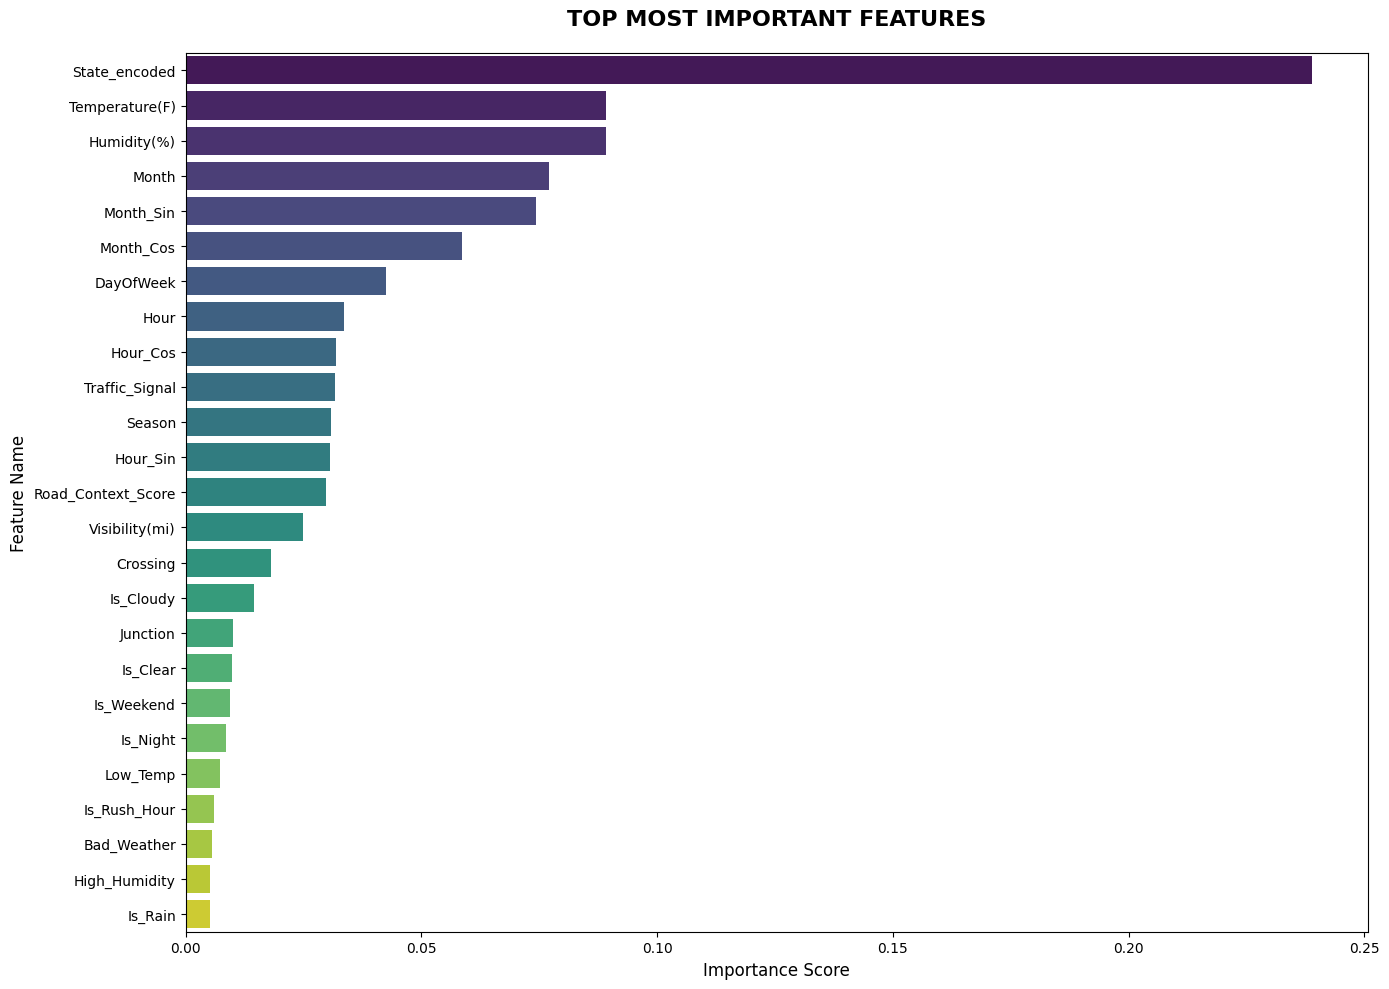


📈 Feature Importance Statistics:
   • Median importance: 0.010097
   • Mean importance: 0.030303
   • Max importance: 0.238873
   • Min importance: 0.000466

🔍 Selecting features with importance > median...

✅ FEATURE SELECTION RESULTS:
   • Original features: 33
   • Selected features: 17 (51.5%)
   • Removed features: 16 (48.5%)

📋 Selected Features (17):
    1. Crossing                       (importance: 0.018080)
    2. DayOfWeek                      (importance: 0.042477)
    3. Hour                           (importance: 0.033666)
    4. Hour_Cos                       (importance: 0.031990)
    5. Hour_Sin                       (importance: 0.030542)
    6. Humidity(%)                    (importance: 0.089057)
    7. Is_Cloudy                      (importance: 0.014425)
    8. Junction                       (importance: 0.010097)
    9. Month                          (importance: 0.077153)
   10. Month_Cos                      (importance: 0.058617)
   11. Month_Sin             

In [158]:
def select_best_features(X_train, y_train, X_test):
    """
    Perform feature selection using Random Forest feature importance
    Keep only features with importance above median threshold
    """
    print("\n" + "="*80)
    print("🔍 PERFORMING FEATURE SELECTION...")
    print("="*80)
    
    # 1. Initialize a model to evaluate feature importance
    selector_model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=20, 
        random_state=42, 
        n_jobs=-1,
        class_weight='balanced'  # Important because data is imbalanced
    )
    
    print("🌲 Training Random Forest to evaluate feature importance...")
    selector_model.fit(X_train, y_train)
    print("✅ Training completed!")
    
    # 2. Get the importance of each feature
    importances = selector_model.feature_importances_
    feature_names = X_train.columns
    
    # Create a DataFrame for easier visualization
    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # 3. Visualize (Data Storytelling)
    print("\n📊 Creating feature importance visualization...")
    plt.figure(figsize=(14, 10))
    
    # Plot top 25 features (or all if less than 25)
    n_features_to_plot = min(25, len(feature_imp_df))
    
    sns.barplot(
        data=feature_imp_df.head(n_features_to_plot),
        x='Importance', 
        y='Feature', 
        palette='viridis'
    )
    plt.title('TOP MOST IMPORTANT FEATURES', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📈 Feature Importance Statistics:")
    print(f"   • Median importance: {feature_imp_df['Importance'].median():.6f}")
    print(f"   • Mean importance: {feature_imp_df['Importance'].mean():.6f}")
    print(f"   • Max importance: {feature_imp_df['Importance'].max():.6f}")
    print(f"   • Min importance: {feature_imp_df['Importance'].min():.6f}")
    
    # 4. Feature selection using median threshold
    print("\n🔍 Selecting features with importance > median...")
    selection_threshold = "median"  # Keep features with importance > median (top 50%)
    
    sfm = SelectFromModel(selector_model, threshold=selection_threshold, prefit=True)
    
    # Transform the data (remove weak features)
    X_train_selected = sfm.transform(X_train)
    X_test_selected = sfm.transform(X_test)
    
    # Get the names of the selected features
    selected_features = feature_names[sfm.get_support()]
    
    # Convert back to DataFrame (IMPORTANT: preserve index)
    X_train_final = pd.DataFrame(
        X_train_selected, 
        columns=selected_features, 
        index=X_train.index
    )
    X_test_final = pd.DataFrame(
        X_test_selected, 
        columns=selected_features, 
        index=X_test.index
    )
    
    # Calculate removed features
    removed_features = list(set(feature_names) - set(selected_features))
    
    # Print results
    print(f"\n✅ FEATURE SELECTION RESULTS:")
    print(f"   • Original features: {X_train.shape[1]}")
    print(f"   • Selected features: {X_train_final.shape[1]} ({X_train_final.shape[1]/X_train.shape[1]*100:.1f}%)")
    print(f"   • Removed features: {len(removed_features)} ({len(removed_features)/X_train.shape[1]*100:.1f}%)")
    
    print(f"\n📋 Selected Features ({len(selected_features)}):")
    for i, feat in enumerate(sorted(selected_features), 1):
        imp = feature_imp_df[feature_imp_df['Feature'] == feat]['Importance'].values[0]
        print(f"   {i:2d}. {feat:<30} (importance: {imp:.6f})")
    
    if removed_features:
        print(f"\n🗑️  Removed Features ({len(removed_features)}):")
        for i, feat in enumerate(sorted(removed_features), 1):
            imp = feature_imp_df[feature_imp_df['Feature'] == feat]['Importance'].values[0]
            print(f"   {i:2d}. {feat:<30} (importance: {imp:.6f})")
    
    print("\n" + "="*80)
    
    return X_train_final, X_test_final, feature_imp_df


# Run feature selection
print("🚀 Starting feature selection process...")
X_train_final, X_test_final, importance_df = select_best_features(
    X_train_featured, 
    y_train_cleaned, 
    X_test_featured
)

# Verify shapes
print(f"\n✅ FINAL DATASET SHAPES:")
print(f"   • X_train_final: {X_train_final.shape}")
print(f"   • X_test_final: {X_test_final.shape}")
print(f"   • y_train: {y_train_cleaned.shape}")
print(f"   • y_test: {y_test_cleaned.shape}")

In [159]:
print("\n📉 Performing final memory optimization on SELECTED features...")
X_train_final = reduce_mem_usage(X_train_final) 
X_test_final = reduce_mem_usage(X_test_final)   

print(f"\n✅ Final dataset ready for modeling:")
print(f"   • X_train shape: {X_train_final.shape}")
print(f"   • X_test shape: {X_test_final.shape}")


📉 Performing final memory optimization on SELECTED features...
   ℹ️  Initial memory usage: 323.22 MB
   ✅ Memory usage after optimization: 161.61 MB (Reduced by 50.0%)
   ℹ️  Initial memory usage: 80.81 MB
   ✅ Memory usage after optimization: 40.40 MB (Reduced by 50.0%)

✅ Final dataset ready for modeling:
   • X_train shape: (2492096, 17)
   • X_test shape: (623019, 17)


### Save Data

In [160]:
# Save final feature-engineered datasets
X_train_final.to_csv('dataset/processed/X_train_featured.csv', index=False)
X_test_final.to_csv('dataset/processed/X_test_featured.csv', index=False)

# Also save target variables
y_train_cleaned.to_csv('dataset/processed/y_train.csv', index=False)
y_test_cleaned.to_csv('dataset/processed/y_test.csv', index=False)

print("✅ Feature-engineered datasets saved successfully!")
print("   • dataset/processed/X_train_featured.csv")
print("   • dataset/processed/X_test_featured.csv")
print("   • dataset/processed/y_train.csv")
print("   • dataset/processed/y_test.csv")

✅ Feature-engineered datasets saved successfully!
   • dataset/processed/X_train_featured.csv
   • dataset/processed/X_test_featured.csv
   • dataset/processed/y_train.csv
   • dataset/processed/y_test.csv
